# Housing Demand Prediction (Linear Regression Model)
### Predicting severe housing deprivation from immigration inflow

## API Calls

In [1]:
import requests
import itertools
import pandas as pd
import numpy as np

EUROSTAT_BASE = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"

def get_stat(url, params):
    """Fetch a Eurostat dataset and return raw JSON."""
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    return response.json()

def eurostat_to_df(data):
    """Convert Eurostat JSON response to a flat DataFrame."""
    dims = {
        dim: list(info["category"]["label"].values())
        for dim, info in data["dimension"].items()
    }
    keys = list(itertools.product(*dims.values()))
    values = [data["value"].get(str(i)) for i in range(len(keys))]
    df = pd.DataFrame(keys, columns=dims.keys())
    df["value"] = values
    return df

# immigration: total citizenship, total sex, total age
immigration_raw = get_stat(
    f"{EUROSTAT_BASE}/tps00176",
    params={
        "format": "JSON", "lang": "en",
        "citizen": "TOTAL",
        "sex": "T",
        "age": "TOTAL",
        "sinceTimePeriod": "2010",
    }
)

# severe housing deprivation (target variable)
deprivation_raw = get_stat(
    f"{EUROSTAT_BASE}/ilc_lvho50b",
    params={
        "format": "JSON", "lang": "en",
        "sinceTimePeriod": "2010",
    }
)

df_immigration = eurostat_to_df(immigration_raw)
df_deprivation = eurostat_to_df(deprivation_raw)

df_immigration.to_csv("immigration.csv", index=False)
df_deprivation.to_csv("deprivation.csv", index=False)

print("immigration:", df_immigration.shape)
print("deprivation:", df_deprivation.shape)

immigration: (1248, 9)
deprivation: (39744, 7)


## Initial Exploratory Data Analysis (EDA)

In [2]:
df_immigration = pd.read_csv("immigration.csv")
df_deprivation = pd.read_csv("deprivation.csv")

for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
]:
    print(f"=== {label} ===")
    print("  shape:",   df.shape)
    print("  columns:", df.columns.tolist())
    print("  nulls:\n", df.isnull().sum().to_string())
    print()

=== immigration ===
  shape: (1248, 9)
  columns: ['freq', 'citizen', 'agedef', 'age', 'unit', 'sex', 'geo', 'time', 'value']
  nulls:
 freq         0
citizen      0
agedef       0
age          0
unit         0
sex          0
geo          0
time         0
value      402

=== deprivation ===
  shape: (39744, 7)
  columns: ['freq', 'unit', 'quantile', 'hhcomp', 'geo', 'time', 'value']
  nulls:
 freq           0
unit           0
quantile       0
hhcomp         0
geo            0
time           0
value       5501



In [3]:
# inspect dimension values so we know how to filter each dataset
for label, df in [
    ("immigration", df_immigration),
    ("deprivation", df_deprivation),
]:
    print(f"=== {label} ===")
    for col in df.columns:
        if col not in ["value", "geo", "time"]:
            print(f"  {col}: {df[col].unique()[:8]}")
    print()

=== immigration ===
  freq: ['Annual']
  citizen: ['Total']
  agedef: ['Age reached during the year' 'Age in completed years']
  age: ['Total']
  unit: ['Number']
  sex: ['Total']

=== deprivation ===
  freq: ['Annual']
  unit: ['Percentage']
  quantile: ['Total' 'First quintile' 'Second quintile' 'Third quintile'
 'Fourth quintile' 'Fifth quintile']
  hhcomp: ['Total' 'One adult with dependent children'
 'Two adults with one dependent child'
 'Two adults with two dependent children'
 'Two adults with three or more dependent children'
 'Two or more adults with dependent children'
 'Three or more adults with dependent children'
 'Household without dependent children']



## Clean Datasets

In [4]:
def clean_df(df, value_col):
    # standardise column names, drop nulls, remove EU aggregates
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
    )
    df = df.rename(columns={"value": value_col})
    df = df.dropna(subset=[value_col])
    if "time" in df.columns:
        df = df.rename(columns={"time": "year"})
    df = df[~df["geo"].str[:4].isin(["Euro", "EU27", "EU28"])]
    df["year"]    = df["year"].astype(int)
    df[value_col] = df[value_col].astype(float)
    return df

df_immigration_clean = clean_df(df_immigration, "immigration_count")
df_deprivation_clean = clean_df(df_deprivation, "deprivation_rate")

# immigration: keep Total rows across all breakdown dimensions
for col in ["citizen", "sex", "age", "agedef", "unit"]:
    if col in df_immigration_clean.columns:
        vals = df_immigration_clean[col].unique()
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_immigration_clean = df_immigration_clean[
                df_immigration_clean[col] == total_val[0]
            ].copy()

# deprivation: keep Total quantile and Total household composition
for col in ["quantile", "hhcomp"]:
    if col in df_deprivation_clean.columns:
        vals = df_deprivation_clean[col].unique()
        print(f"{col} values:", vals)
        total_val = [v for v in vals if "total" in str(v).lower()]
        if total_val:
            df_deprivation_clean = df_deprivation_clean[
                df_deprivation_clean[col] == total_val[0]
            ].copy()

print("immigration clean:", df_immigration_clean.shape)
print("deprivation clean:", df_deprivation_clean.shape)

df_immigration_clean.to_csv("immigration_clean.csv", index=False)
df_deprivation_clean.to_csv("deprivation_clean.csv", index=False)
print("Saved cleaned CSVs.")

# check for year gaps
for label, df in [
    ("immigration", df_immigration_clean),
    ("deprivation", df_deprivation_clean),
]:
    years = sorted(df["year"].unique())
    gaps  = [y for i, y in enumerate(years[1:], 1) if y - years[i-1] > 1]
    print(f"{label}: {years[0]}-{years[-1]}, gaps: {gaps if gaps else 'none'}")

quantile values: ['Total' 'First quintile' 'Second quintile' 'Third quintile'
 'Fourth quintile' 'Fifth quintile']
hhcomp values: ['Total' 'One adult with dependent children'
 'Two adults with one dependent child'
 'Two adults with two dependent children'
 'Two adults with three or more dependent children'
 'Two or more adults with dependent children'
 'Three or more adults with dependent children'
 'Household without dependent children'
 'Household with dependent children']
immigration clean: (822, 9)
deprivation clean: (543, 7)
Saved cleaned CSVs.
immigration: 2013-2024, gaps: none
deprivation: 2010-2025, gaps: none


## Data Visualizations

In [5]:
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

df_immigration_clean = pd.read_csv("immigration_clean.csv")
df_deprivation_clean = pd.read_csv("deprivation_clean.csv")

In [6]:
# plot 1: EU average deprivation rate over time
# tracks whether EU-wide housing conditions are improving

eu_dep = df_deprivation_clean.groupby("year")["deprivation_rate"].mean().reset_index()
eu_immig = df_immigration_clean.groupby("year")["immigration_count"].mean().reset_index()

fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=eu_dep["year"], y=eu_dep["deprivation_rate"],
    name="Deprivation rate (%)", line=dict(color="#30D836"), mode="lines+markers"
))
fig1.update_layout(
    title="EU average severe housing deprivation rate over time",
    xaxis_title="Year", yaxis_title="Rate (%)"
)
fig1.show()

In [7]:
# plot 2: severe housing deprivation by country (latest year)

latest_dep = (
    df_deprivation_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["deprivation_rate"].first()
    .sort_values("deprivation_rate")
)

fig2 = px.bar(
    latest_dep, x="deprivation_rate", y="geo", orientation="h",
    title="Severe housing deprivation rate by country (latest year)",
    labels={"deprivation_rate": "Deprivation rate (%)", "geo": ""},
    color_discrete_sequence=["#378ADD"]
)
fig2.show()

In [8]:
# plot 3: immigration inflow by country (latest year)

latest_immig = (
    df_immigration_clean
    .sort_values("year", ascending=False)
    .groupby("geo", as_index=False)["immigration_count"].first()
    .sort_values("immigration_count")
)

fig3 = px.bar(
    latest_immig, x="immigration_count", y="geo", orientation="h",
    title="Immigration inflow by country (latest year)",
    labels={"immigration_count": "Number of immigrants", "geo": ""}, color_discrete_sequence=["#ED9F0F"]
)
fig3.show()

In [9]:
# plot 4: deprivation over time for top 5 worst countries

top5 = latest_dep.sort_values("deprivation_rate", ascending=False).head(5)["geo"].tolist()
dep_top5 = df_deprivation_clean[df_deprivation_clean["geo"].isin(top5)]

fig5 = px.line(
    dep_top5, x="year", y="deprivation_rate", color="geo", markers=True,
    title="Severe housing deprivation over time - 5 highest-deprivation countries",
    labels={"deprivation_rate": "Deprivation rate (%)", "year": "Year", "geo": "Country"}
)
fig5.show()

## Aggregate, Engineer Features, and Merge

In [10]:
def aggregate_to_country_year(df, value_col):
    """Mean-aggregate all extra dimensions down to geo x year."""
    return df.groupby(["geo", "year"], as_index=False)[value_col].mean()

agg_immigration = aggregate_to_country_year(df_immigration_clean, "immigration_count")
agg_deprivation = aggregate_to_country_year(df_deprivation_clean, "deprivation_rate")

# merge on country and year, starting from the target
merged = (
    agg_deprivation
    .merge(agg_immigration, on=["geo", "year"], how="inner")
)
merged = merged.dropna()
print(f"Merged: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")
print(f"Years: {merged['year'].min()} - {merged['year'].max()}")
merged.head()

Merged: 382 rows, 33 countries
Years: 2013 - 2024


,geo,year,deprivation_rate,immigration_count
0,Austria,2013,31.6,101866.0
1,Austria,2014,31.0,116262.0
2,Austria,2015,31.2,166323.0
3,Austria,2016,31.2,129509.0
4,Austria,2017,31.2,111801.0


In [11]:
# feature engineering

# log-transform immigration count (fixes right skew)
merged["log_immigration"] = np.log1p(merged["immigration_count"])

# 1-year lagged immigration (last year's inflow predicts this year's deprivation)
merged = merged.sort_values(["geo", "year"])
merged["immigration_lag1"] = merged.groupby("geo")["log_immigration"].shift(1)

# drop rows where lag is NaN
merged = merged.dropna(subset=["immigration_lag1"])
print(f"After lag: {merged.shape[0]} rows, {merged['geo'].nunique()} countries")

country_dummies = pd.get_dummies(merged["geo"], prefix="country", drop_first=True)
merged_with_dummies = pd.concat([
    merged.reset_index(drop=True),
    country_dummies.reset_index(drop=True)
], axis=1)

print(f"Shape with country dummies: {merged_with_dummies.shape}")
merged_with_dummies.to_csv("merged_linreg.csv", index=False)
merged_with_dummies.head()

After lag: 349 rows, 33 countries
Shape with country dummies: (349, 38)


,geo,year,deprivation_rate,immigration_count,log_immigration,immigration_lag1,country_Belgium,country_Bulgaria,country_Croatia,country_Cyprus,...,country_Norway,country_Poland,country_Portugal,country_Romania,country_Slovakia,country_Slovenia,country_Spain,country_Sweden,country_Switzerland,country_United Kingdom
0,Austria,2014,31.0,116262.0,11.663610,11.531423,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,Austria,2015,31.2,166323.0,12.021693,11.663610,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,Austria,2016,31.2,129509.0,11.771513,12.021693,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Austria,2017,31.2,111801.0,11.624485,11.771513,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,Austria,2018,31.0,105633.0,11.567736,11.624485,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Linear Regression Model

**Features (X):**
- immigration_lag1: log immigration from the previous year
- year: captures overall EU trend over time
- Country dummies: one per country (minus one reference country); these capture each country's baseline deprivation level

**Target (y):** deprivation_rate: real measured Eurostat outcome, not derived from inputs.

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("merged_linreg.csv")

continuous_cols = ["immigration_lag1", "year"]

dummy_cols = [c for c in df.columns if c.startswith("country_")]

target_col = "deprivation_rate"

X_continuous = df[continuous_cols].to_numpy()
X_dummies    = df[dummy_cols].to_numpy().astype(float)
y            = df[target_col].to_numpy()

(
    X_cont_train, X_cont_test,
    X_dum_train,  X_dum_test,
    y_train,      y_test
) = train_test_split(
    X_continuous, X_dummies, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_cont_train_scaled = scaler.fit_transform(X_cont_train)
X_cont_test_scaled  = scaler.transform(X_cont_test)

X_train = np.hstack([X_cont_train_scaled, X_dum_train])
X_test  = np.hstack([X_cont_test_scaled,  X_dum_test])

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Features: {X_train.shape[1]} ({len(continuous_cols)} continuous + {len(dummy_cols)} country dummies)")

Train: 244 rows, Test: 105 rows
Features: 34 (2 continuous + 32 country dummies)


In [13]:
def my_linear_regression(X_train, y_train, X_test):
    """
    Linear regression using the closed-form normal equation.
    Solves: w = (X^T X)^{-1} X^T y

    Args:
        X_train: numpy array (n_samples, n_features)
        y_train: numpy array (n_samples,)
        X_test:  numpy array (m_samples, n_features)

    Returns:
        y_pred:  numpy array (m_samples,) - predicted deprivation rates
        weights: numpy array (n_features + 1,) - [intercept, coef1, coef2, ...]
    """
    n = X_train.shape[0]
    X_b = np.column_stack([np.ones(n), X_train])

    weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train

    m = X_test.shape[0]
    X_test_b = np.column_stack([np.ones(m), X_test])
    y_pred = X_test_b @ weights

    return y_pred, weights


y_pred, weights = my_linear_regression(X_train, y_train, X_test)

print("Continuous feature coefficients (after scaling):")
labels = ["intercept"] + continuous_cols
for label, w in zip(labels, weights[:len(labels)]):
    print(f"  {label:25s}: {w:.4f}")

Continuous feature coefficients (after scaling):
  intercept                : 30.9322
  immigration_lag1         : 0.2323
  year                     : 0.0715


In [14]:
# success metrics
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"R2:   {r2:.4f}")

MSE:  6.9064
R2:   0.9816


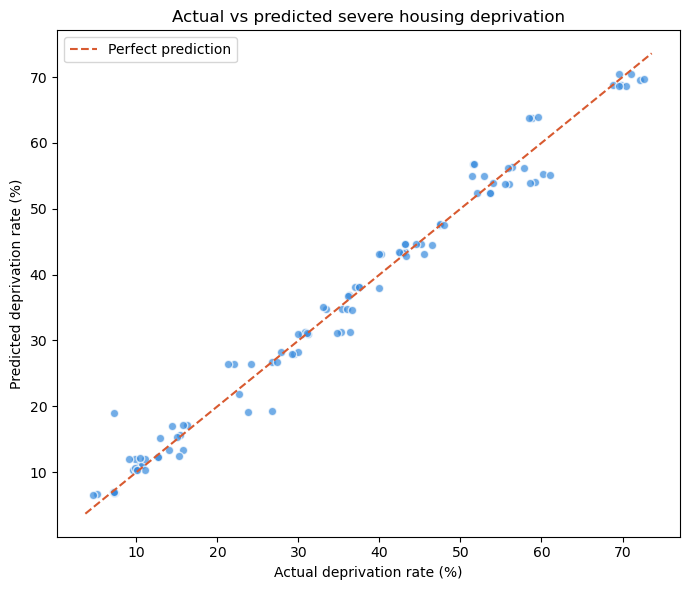

In [15]:
# plot 5: actual vs predicted deprivation rate

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.7, color="#378ADD", edgecolors="white")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
ax.plot(lims, lims, "--", color="#D85A30", label="Perfect prediction")
ax.set_xlabel("Actual deprivation rate (%)")
ax.set_ylabel("Predicted deprivation rate (%)")
ax.set_title("Actual vs predicted severe housing deprivation")
ax.legend()
plt.tight_layout()
plt.show()

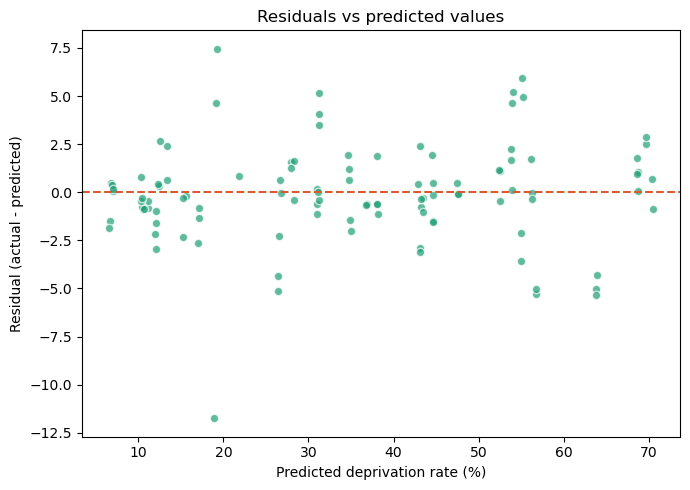

In [16]:
# plot 6: residuals

residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.7, color="#1D9E75", edgecolors="white")
ax.axhline(0, color="#D85A30", linestyle="--")
ax.set_xlabel("Predicted deprivation rate (%)")
ax.set_ylabel("Residual (actual - predicted)")
ax.set_title("Residuals vs predicted values")
plt.tight_layout()
plt.show()

## Interpret and Apply the Model

The coefficients tell us:
- immigration_lag1: whether last year's immigration inflow is associated with higher or lower deprivation this year
- year: whether deprivation is generally improving or worsening across Europe over time
- Country dummies: the baseline deprivation level for each country relative to the reference country

In [17]:
# predict deprivation for the most recent year per country

latest = (
    df.sort_values("year", ascending=False)
    .groupby("geo", as_index=False)
    .first()
)

X_latest_cont = scaler.transform(latest[continuous_cols].to_numpy())
X_latest_dum  = latest[dummy_cols].to_numpy().astype(float)
X_latest      = np.hstack([X_latest_cont, X_latest_dum])

n_latest   = X_latest.shape[0]
X_latest_b = np.column_stack([np.ones(n_latest), X_latest])
latest["predicted_deprivation"] = X_latest_b @ weights

result = (
    latest[["geo", "year", "deprivation_rate", "predicted_deprivation"]]
    .sort_values("predicted_deprivation", ascending=False)
)
print("Countries ranked by predicted deprivation (highest = most need for ESF+ funding):")
print(result.to_string(index=False))

Countries ranked by predicted deprivation (highest = most need for ESF+ funding):
            geo  year  deprivation_rate  predicted_deprivation
         Cyprus  2024              70.1              70.807582
          Malta  2024              62.9              69.906495
        Ireland  2024              66.8              68.873573
        Belgium  2024              57.9              63.954249
 United Kingdom  2018              55.8              56.819562
          Spain  2024              55.4              56.598935
    Netherlands  2024              58.7              55.238628
     Luxembourg  2024              57.5              53.999611
         Norway  2024              52.6              52.679645
        Finland  2024              46.9              47.834701
    Switzerland  2024              42.4              44.830390
        Denmark  2024              42.4              43.410289
         France  2024              40.0              43.106028
         Sweden  2024              3

In [18]:
# plot 7: predicted deprivation by country

fig8 = px.bar(
    result.sort_values("predicted_deprivation"),
    x="predicted_deprivation", y="geo", orientation="h",
    title="Predicted severe housing deprivation by country",
    labels={"predicted_deprivation": "Predicted deprivation rate (%)", "geo": ""}, color_discrete_sequence=["#ED0F52"]
)
fig8.show()